## Passo 1: Carregar e Pré-Processar os Dados

Carregar Bibliotecas Necessárias

Explicação: Aqui, estamos importando as bibliotecas essenciais para análise e visualização de dados (Pandas para manipulação de dados, NumPy para operações numéricas, Matplotlib e Seaborn para visualização).

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# Set plot style for better visuals
sns.set(style="whitegrid")

## Passo 2: Carregar o Conjunto de Dados
Explicação: Neste passo, estamos carregando o conjunto de dados do Titanic a partir de um URL fornecido e exibindo as primeiras linhas para verificar como os dados estão organizados

In [2]:

# Carregar o conjunto de dados do Titanic a partir do URL fornecido
url = 'https://github.com/Magno-Rodrigues/Kaggle/blob/main//titanic_dataset/Titanic-Dataset.csv?raw=true'
df = pd.read_csv(url)

# Exibir as primeiras linhas do conjunto de dados para entender sua estrutura
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Passo 3: Visão Geral dos Dados
Explicação: Aqui, estamos verificando informações básicas sobre o conjunto de dados, como os tipos de dados de cada coluna e se há valores ausentes. Também exibimos estatísticas sumárias para colunas numéricas para entender melhor a distribuição dos dados.

In [3]:
# Exibir informações básicas sobre o conjunto de dados
df.info()

# Exibir estatísticas sumárias para colunas numéricas
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Passo 4: Visualização de Dados
##### 4.1: Distribuição de Características Numéricas

Explicação: Este passo envolve a criação de histogramas para visualizar a distribuição das características numéricas no conjunto de dados, o que nos ajuda a entender melhor como os dados estão distribuídos.

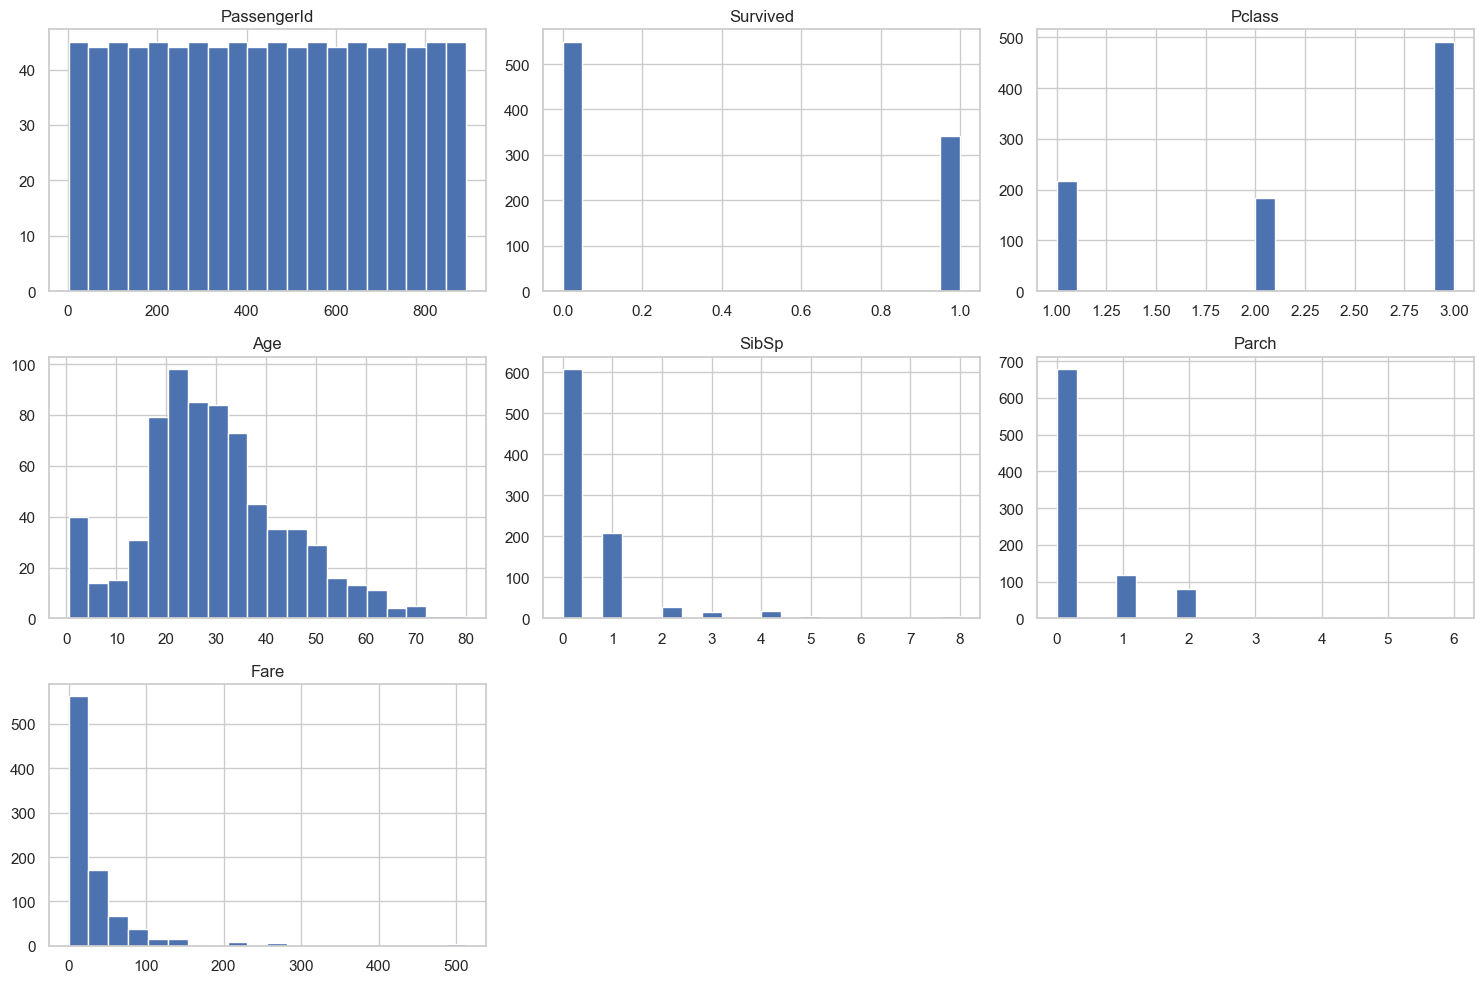

In [4]:
# Plotar histogramas para características numéricas
df.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

###### 4.2: Distribuição de Características Categóricas
Explicação: Aqui, estamos visualizando a distribuição das características categóricas (como classe, sexo, número de irmãos/cônjuges a bordo, número de pais/filhos a bordo, e porto de embarque) usando gráficos de contagem. Isso nos permite ver a frequência de cada categoria nas variáveis categóricas.

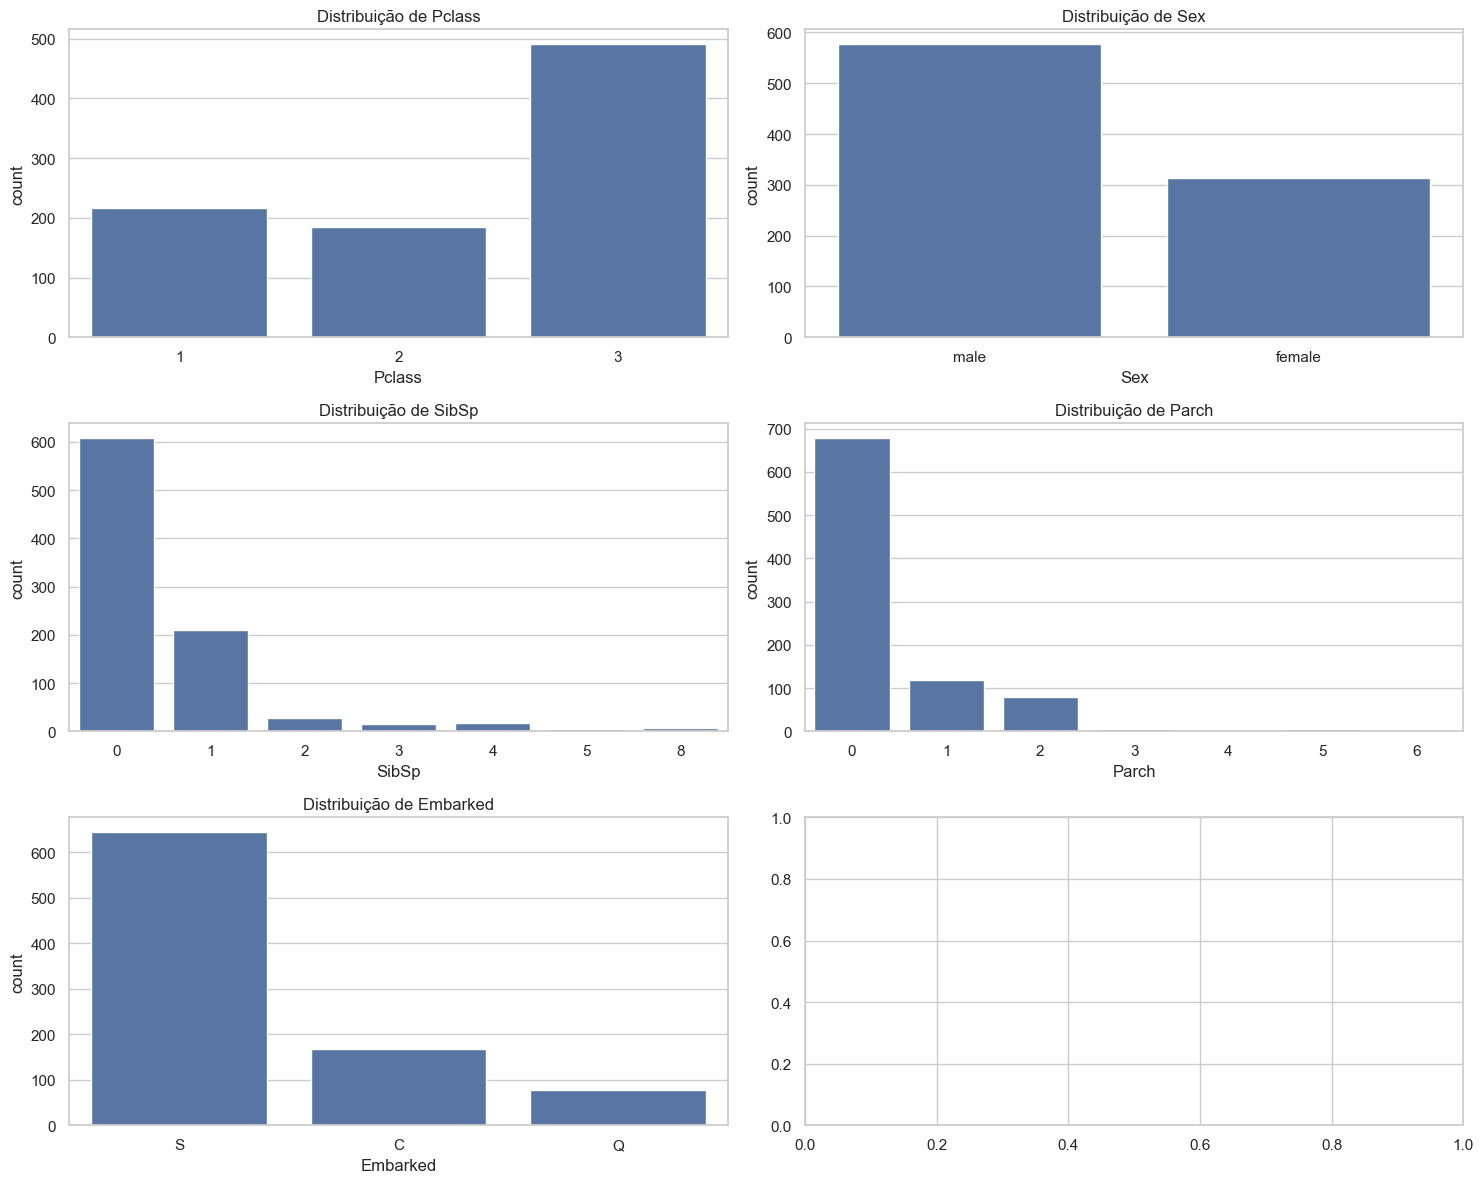

In [5]:
# Plotar gráficos de contagem para características categóricas
features_categoricas = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, cat_feature in zip(axes, features_categoricas):
    sns.countplot(data=df, x=cat_feature, ax=ax)
    ax.set_title(f'Distribuição de {cat_feature}')

plt.tight_layout()
plt.show()


##### 4.3: Taxa de Sobrevivência por Características Categóricas
Explicação: Aqui, estamos visualizando a distribuição das características categóricas (como classe, sexo, número de irmãos/cônjuges a bordo, número de pais/filhos a bordo, e porto de embarque) usando gráficos de contagem. Isso nos permite ver a frequência de cada categoria nas variáveis categóricas.

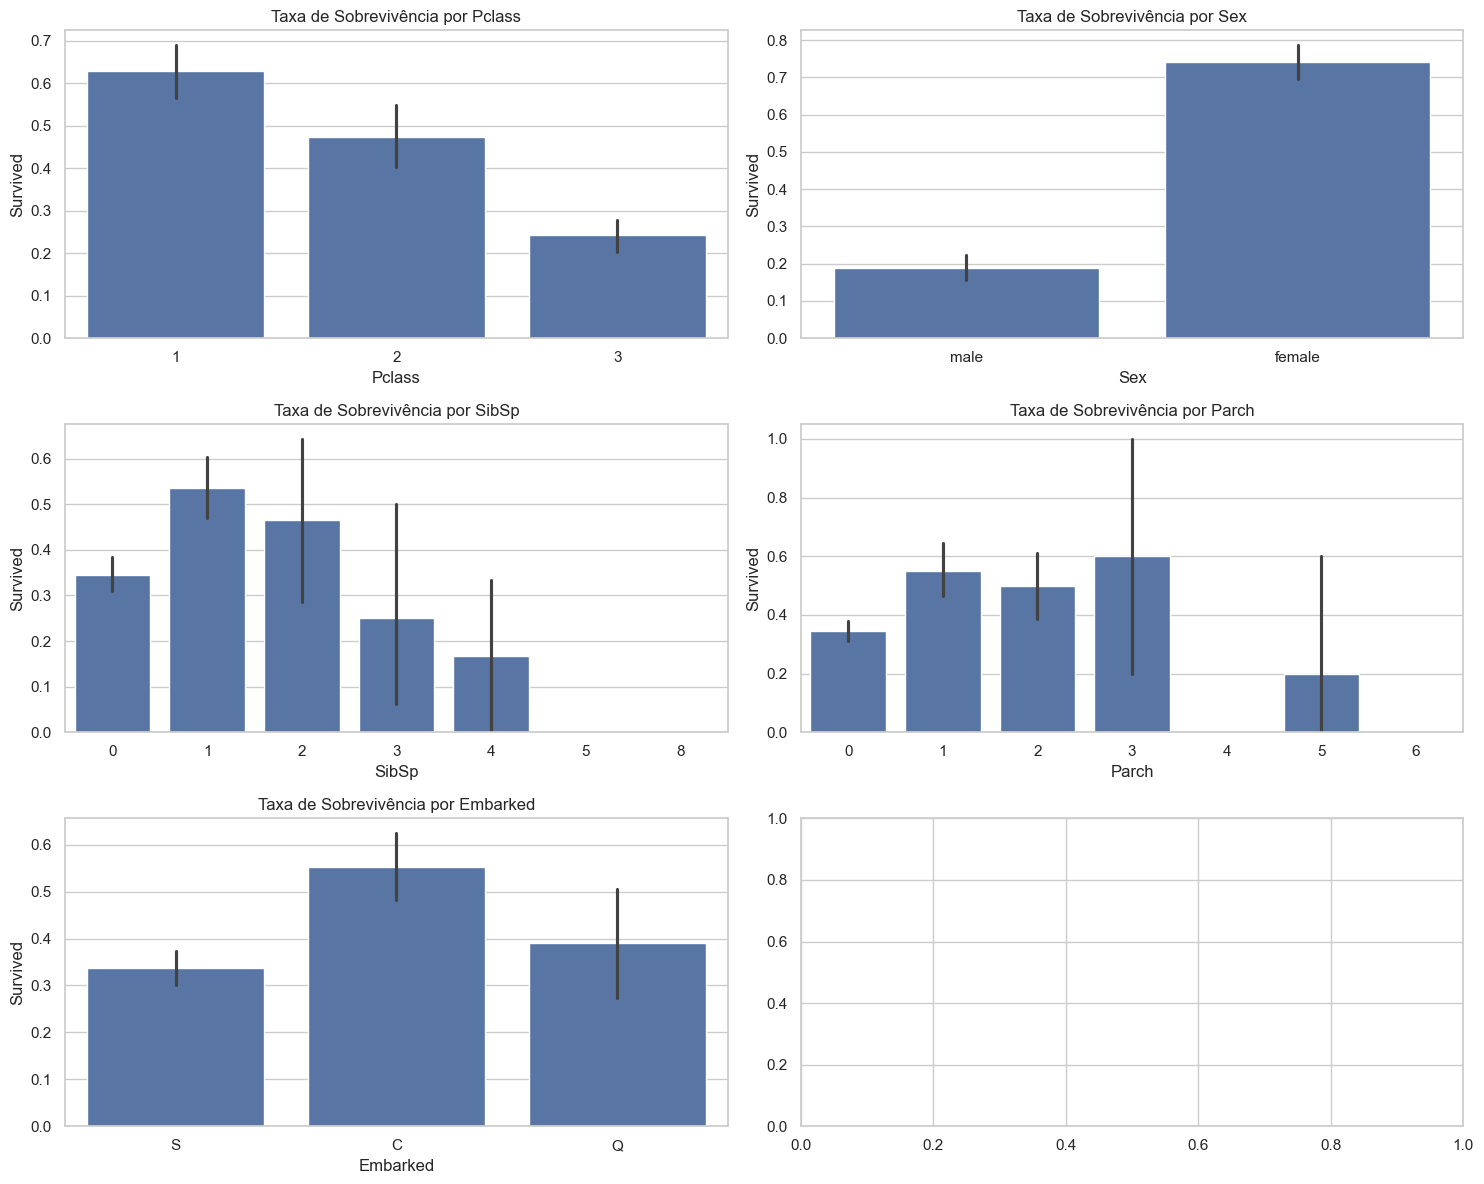

In [6]:
# Plotar taxa de sobrevivência por características categóricas
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, cat_feature in zip(axes, features_categoricas):
    sns.barplot(data=df, x=cat_feature, y='Survived', ax=ax)
    ax.set_title(f'Taxa de Sobrevivência por {cat_feature}')

plt.tight_layout()
plt.show()


## Passo 5: Engenharia de Características
Explicação: Aqui, estamos realizando a engenharia de características, o que envolve o tratamento de valores ausentes (preenchimento com moda/mediana), descarte de colunas não relevantes (como 'Cabin'), e conversão de características categóricas em variáveis numéricas usando codificação one-hot (para 'Sex' e 'Embarked').

In [7]:
# Preencher valores ausentes para 'Embarked' com o modo
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Preencher valores ausentes para 'Age' com a mediana
df['Age'] = df['Age'].fillna(df['Age'].median())

# Preencher valores ausentes para 'Fare' com a mediana
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# Descartar a coluna 'Cabin'
df = df.drop(columns=['Cabin'])

# Converter características categóricas em numéricas
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Exibir as primeiras linhas
df.head()


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


## Passo 6: Dividir os Dados em Conjuntos de Treinamento e Teste
Explicação: Aqui, estamos dividindo os dados em conjuntos de treinamento e teste para preparar o modelo de machine learning. Os dados são divididos em 80% para treinamento e 20% para teste, garantindo que tenhamos conjuntos separados para treinar e avaliar o desempenho do modelo.

In [8]:
from sklearn.model_selection import train_test_split

# Definir variáveis de entrada (X) e de saída (y)
X = df.drop(columns=['Survived', 'Name', 'Ticket'])
y = df['Survived']

# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Passo 7: Treinar um Modelo de Machine Learning (Random Forest)
Explicação: Neste passo, estamos treinando um modelo de Random Forest usando os dados de treinamento. O modelo é configurado com 100 árvores de decisão (n_estimators=100) e treinado para prever se os passageiros sobreviveram ou não com base nas características fornecidas.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Inicializar o modelo Random Forest
modelo_rf_unscaled = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinar o modelo com dados de treinamento
modelo_rf_unscaled.fit(X_train, y_train)

# Fazer previsões com dados de teste
y_pred = modelo_rf_unscaled.predict(X_test)

## Passo 8: Avaliar o Modelo
Explicação: Aqui, estamos avaliando o desempenho do modelo de Random Forest calculando a precisão (proporção de previsões corretas), exibindo a matriz de confusão (que mostra a contagem de previsões corretas e incorretas), e o relatório de classificação que fornece métricas como precisão, recall, e F1-score para cada classe.

In [10]:
# Calcular a precisão do modelo
accuracy_rf_unscaled = accuracy_score(y_test, y_pred)

# Exibir a matriz de confusão
matriz_confusao = confusion_matrix(y_test, y_pred)

# Exibir o relatório de classificação
relatorio_classificacao = classification_report(y_test, y_pred)

print(accuracy_rf_unscaled, matriz_confusao, relatorio_classificacao)

0.8212290502793296 [[92 13]
 [19 55]]               precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## Passo 9: Visualizar a Matriz de Confusão - Modelo Random Forest
Explicação: Este código plota uma matriz de confusão visual para analisar melhor o desempenho do modelo. A matriz de confusão é uma ferramenta que nos ajuda a entender a taxa de acertos e erros das previsões feitas pelo modelo.

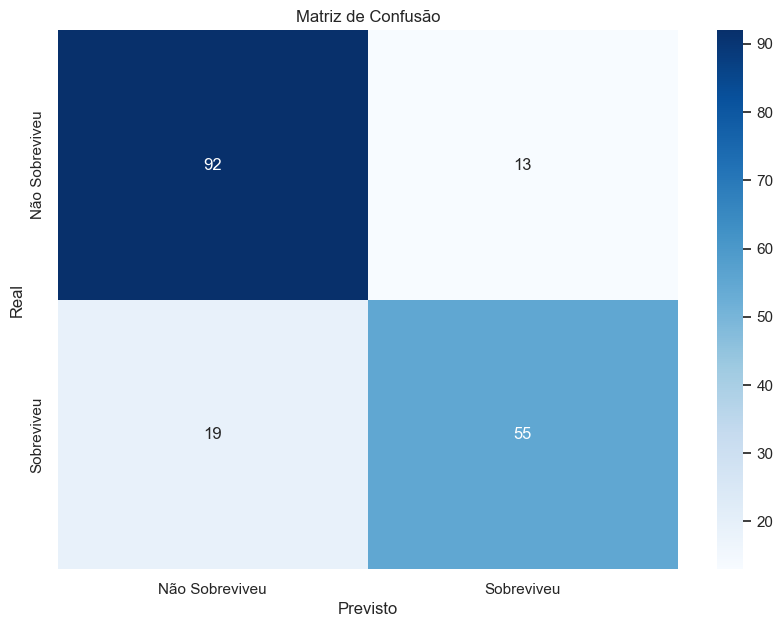

In [11]:
# Plotar a matriz de confusão para visualizar o desempenho do modelo
plt.figure(figsize=(10, 7))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Sobreviveu', 'Sobreviveu'], yticklabels=['Não Sobreviveu', 'Sobreviveu'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

## Passo 10: Melhorar a Precisão Utilizando Diferentes Modelos
##### 10.1: Escalonamento dos Dados (Opcional)

Explicação: O escalonamento de dados é importante para muitos algoritmos de machine learning, especialmente aqueles sensíveis à escala das características. Aqui, estamos utilizando o StandardScaler para padronizar as características, o que pode melhorar a performance de modelos como SVM e Regressão Logística.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

# Inicializar o escalonador
scaler = StandardScaler()

# Aplicar o escalonamento aos dados de treinamento e teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inicializar e treinar o modelo RandomForest com dados escalonados
modelo_rf_scaled = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf_scaled.fit(X_train_scaled, y_train)

# Fazer previsões com dados de teste escalonados
y_pred_scaled = modelo_rf_scaled.predict(X_test_scaled)

# Calcular a acurácia do modelo com dados escalonados
accuracy_rf_scaled = accuracy_score(y_test, y_pred_scaled)

# Exibir a acurácia do modelo com dados escalonados
print(f'Acurácia do Random Forest com dados escalonados: {accuracy_rf_scaled:.4f}')


Acurácia do Random Forest com dados escalonados: 0.8268


##### 10.2: Visualizar a Matriz de Confusão e exibindo a tabela de métricas - Modelo Random Forest (Escalonado)

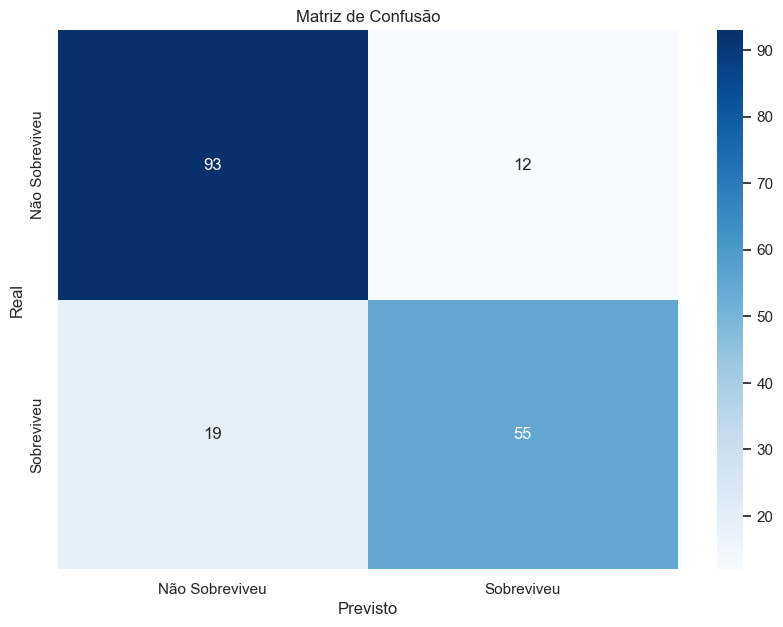

,Métrica,Quantidade
0,Verdadeiros Positivos (VP),55
1,Verdadeiros Negativos (VN),93
2,Falsos Positivos (FP),12
3,Falsos Negativos (FN),19


In [13]:
# Calcular a matriz de confusão
matriz_confusao = confusion_matrix(y_test, y_pred_scaled)

# Plotar a matriz de confusão
plt.figure(figsize=(10, 7))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Sobreviveu', 'Sobreviveu'], yticklabels=['Não Sobreviveu', 'Sobreviveu'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# Calcular VP, VN, FP e FN
VN, FP, FN, VP = matriz_confusao.ravel()

# Criar um DataFrame para exibir os resultados
resultados = pd.DataFrame({
    'Métrica': ['Verdadeiros Positivos (VP)', 'Verdadeiros Negativos (VN)', 'Falsos Positivos (FP)', 'Falsos Negativos (FN)'],
    'Quantidade': [VP, VN, FP, FN]
})

resultados

##### 10.3: Treinar e Avaliar Diferentes Modelos
Vamos agora treinar e avaliar diversos modelos para comparar sua performance.

Explicação: Aqui, estamos treinando e avaliando diferentes modelos de machine learning após realizar o escalonamento dos dados (se aplicável). Cada modelo é treinado com os dados de treinamento escalonados (X_train_scaled) e avaliado usando os dados de teste escalonados (X_test_scaled).

#### Regressão Logística

In [14]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ============================================
# 1. Tratar valores ausentes (NaN)
# ============================================

# Preencher valores faltantes com a média
imputer = SimpleImputer(strategy='mean')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# ============================================
# 2. Escalonar os dados
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# ============================================
# 3. Criar e treinar o modelo
# ============================================

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

# ============================================
# 4. Fazer previsões
# ============================================

y_pred_log_reg = log_reg.predict(X_test_scaled)

# ============================================
# 5. Avaliar o modelo
# ============================================

accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)

print(f'Acurácia da Regressão Logística: {accuracy_log_reg:.4f}')

Acurácia da Regressão Logística: 0.8045


#### Máquina de Vetores de Suporte (SVM)

In [15]:
from sklearn.svm import SVC

# Inicializar o modelo SVM
svm = SVC(kernel='linear', random_state=42)

# Avaliar o modelo SVM
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f'Acurácia da Máquina de Vetores de Suporte (SVM): {accuracy_svm:.4f}')

Acurácia da Máquina de Vetores de Suporte (SVM): 0.7821


#### Gradient Boosting Classifier

In [16]:
from sklearn.ensemble import GradientBoostingClassifier

# Inicializar o modelo Gradient Boosting
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Avaliar o modelo Gradient Boosting
gbc.fit(X_train_scaled, y_train)
y_pred_gbc = gbc.predict(X_test_scaled)
accuracy_gbc = accuracy_score(y_test, y_pred_gbc)
print(f'Acurácia do Gradient Boosting Classifier: {accuracy_gbc:.4f}')

Acurácia do Gradient Boosting Classifier: 0.8156


#### XGBoost Classifier

In [17]:
import xgboost as xgb

# Inicializar o modelo XGBoost
xgboost = xgb.XGBClassifier(n_estimators=100, random_state=42)

# Avaliar o modelo XGBoost
xgboost.fit(X_train_scaled, y_train)
y_pred_xgb = xgboost.predict(X_test_scaled)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'Acurácia do XGBoost Classifier: {accuracy_xgb:.4f}')

Acurácia do XGBoost Classifier: 0.7933


## Passo 11: Comparar a Performance dos Modelos
Explicação: Aqui, estamos criando um DataFrame para comparar a performance de cada modelo, exibindo suas acurácias calculadas anteriormente. Isso nos permite visualizar qual modelo teve o melhor desempenho na previsão de sobrevivência dos passageiros do Titanic.

In [18]:
# Criar um DataFrame com os resultados de cada modelo
modelos = ['Random Forest (Não Escalonado)', 'Random Forest (Escalonado)', 'Regressão Logística', 'SVM', 'Gradient Boosting', 'XGBoost']
acuracias = [accuracy_rf_unscaled, accuracy_rf_scaled, accuracy_log_reg, accuracy_svm, accuracy_gbc, accuracy_xgb]

df_resultados = pd.DataFrame({'Modelo': modelos, 'Acurácia': acuracias})

df_resultados

,Modelo,Acurácia
0,Random Forest (Não Escalonado),0.821229
1,Random Forest (Escalonado),0.826816
2,Regressão Logística,0.804469
3,SVM,0.782123
4,Gradient Boosting,0.815642
5,XGBoost,0.793296


## Passo 12: Criar um Gráfico Interativo para Comparar os Modelos
Para criar um gráfico interativo que permita selecionar múltiplos modelos:

Explicação: Este código cria um gráfico de barras interativo usando Plotly, onde cada barra representa a acurácia de um modelo específico. O gráfico permite selecionar múltiplas barras para comparar facilmente a performance dos modelos escolhidos.

In [19]:
import plotly.graph_objects as go

# Criar figura com múltiplos subplots
fig = go.Figure()

# Adicionar barras para cada modelo
for index, row in df_resultados.iterrows():
    fig.add_trace(go.Bar(
        x=[row['Modelo']],
        y=[row['Acurácia']],
        name=row['Modelo']
    ))

# Atualizar layout do gráfico
fig.update_layout(
    title='Comparação de Modelos: Acurácia',
    xaxis_title='Modelo',
    yaxis_title='Acurácia',
    barmode='group',
    bargap=0.15,
    bargroupgap=0.1,
    showlegend=True
)

# Exibir o gráfico interativo
fig.show()

## Passo 13: Exibindo todas as matrizes de confusão dos modelos trainados, comparando o desempenho

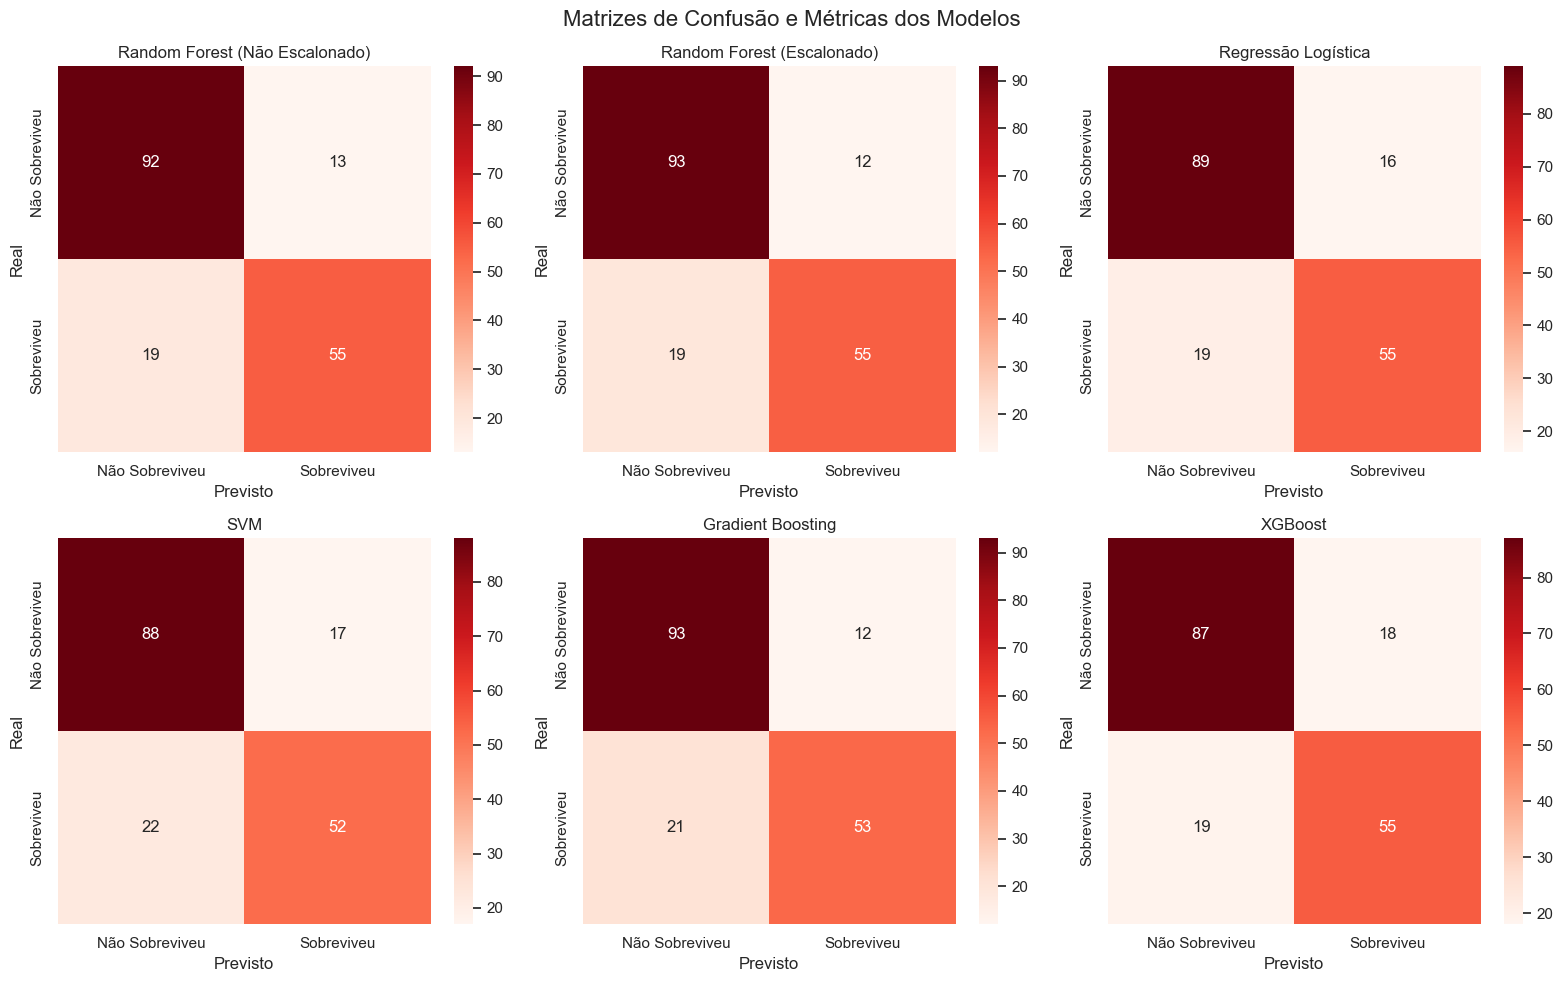

,Modelo,Acurácia,VP,VN,FP,FN
0,Random Forest (Não Escalonado),0.821229,55,92,13,19
1,Random Forest (Escalonado),0.826816,55,93,12,19
2,Regressão Logística,0.804469,55,89,16,19
3,SVM,0.782123,52,88,17,22
4,Gradient Boosting,0.815642,53,93,12,21
5,XGBoost,0.793296,55,87,18,19


In [20]:
# Definir modelos e acurácias
#modelos = ['Random Forest (Não Escalonado)', 'Random Forest (Escalonado)', 'Regressão Logística', 'SVM', 'Gradient Boosting', 'XGBoost']
#acuracias = [accuracy_rf_unscaled, accuracy_rf_scaled, accuracy_log_reg, accuracy_svm, accuracy_gbc, accuracy_xgb]



# Inicializar listas para armazenar matrizes de confusão e métricas
matrizes_confusao = []
vp_values = []
vn_values = []
fp_values = []
fn_values = []

# Calcular matrizes de confusão para cada modelo
for modelo, acuracia in zip(modelos, acuracias):
    if modelo == 'Random Forest (Não Escalonado)':
        y_pred = modelo_rf_unscaled.predict(X_test)
    elif modelo == 'Random Forest (Escalonado)':
        y_pred = modelo_rf_scaled.predict(X_test_scaled)
    elif modelo == 'Regressão Logística':
        y_pred = log_reg.predict(X_test_scaled)
    elif modelo == 'SVM':
        y_pred = svm.predict(X_test_scaled)
    elif modelo == 'Gradient Boosting':
        y_pred = gbc.predict(X_test_scaled)
    elif modelo == 'XGBoost':
        y_pred = xgboost.predict(X_test_scaled)
    
    matriz_confusao = confusion_matrix(y_test, y_pred)
    matrizes_confusao.append(matriz_confusao)
    
    VN, FP, FN, VP = matriz_confusao.ravel()
    vp_values.append(VP)
    vn_values.append(VN)
    fp_values.append(FP)
    fn_values.append(FN)

# Plotar as matrizes de confusão em subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
fig.suptitle('Matrizes de Confusão e Métricas dos Modelos', fontsize=16)

for i, ax in enumerate(axes.flat):
    sns.heatmap(matrizes_confusao[i], annot=True, fmt='d', cmap='Reds', ax=ax,
                xticklabels=['Não Sobreviveu', 'Sobreviveu'], yticklabels=['Não Sobreviveu', 'Sobreviveu'])
    ax.set_title(modelos[i])
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

    # Exibir valores de VP, VN, FP e FN como texto na plotagem
    #text = f'VP={vp_values[i]}\nVN={vn_values[i]}\nFP={fp_values[i]}\nFN={fn_values[i]}\nAcurácia={acuracias[i]:.4f}'
    #ax.text(0.5, 1.1, text, transform=ax.transAxes, verticalalignment='top', horizontalalignment='center', fontsize=12)

plt.tight_layout()
plt.show()

# Exibir os valores de VP, VN, FP e FN e acurácias em uma tabela
resultados = pd.DataFrame({
    'Modelo': modelos,
    'Acurácia': acuracias,
    'VP': vp_values,
    'VN': vn_values,
    'FP': fp_values,
    'FN': fn_values
})

resultados

## Métricas dos Modelos

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Definir modelos
modelos = ['Random Forest (N/E)', 'Random Forest (E)', 'Regressão Logística', 'SVM', 'Gradient Boosting', 'XGBoost']

# Inicializar listas para armazenar métricas
acuracias = []
precisoes = []
recalls = []
f1_scores = []
roc_auc_scores = []

# Calcular métricas para cada modelo
for modelo in modelos:
    if modelo == 'Random Forest (N/E)':
        y_pred = modelo_rf_unscaled.predict(X_test)
    elif modelo == 'Random Forest (E)':
        y_pred = modelo_rf_scaled.predict(X_test_scaled)
    elif modelo == 'Regressão Logística':
        y_pred = log_reg.predict(X_test_scaled)
    elif modelo == 'SVM':
        y_pred = svm.predict(X_test_scaled)
    elif modelo == 'Gradient Boosting':
        y_pred = gbc.predict(X_test_scaled)
    elif modelo == 'XGBoost':
        y_pred = xgboost.predict(X_test_scaled)
    
    # Calcular métricas
    acuracia = accuracy_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    
    # Armazenar métricas nas listas
    acuracias.append(acuracia)
    precisoes.append(precisao)
    recalls.append(recall)
    f1_scores.append(f1)
    roc_auc_scores.append(roc_auc)

# Exibir as métricas em uma tabela
resultados = pd.DataFrame({
    'Modelo': modelos,
    'Acurácia': acuracias,
    'Precisão': precisoes,
    'Recall': recalls,
    'F1-score': f1_scores,
    'ROC AUC Score': roc_auc_scores
})

print("Métricas dos Modelos:")
display(resultados)



Métricas dos Modelos:


,Modelo,Acurácia,Precisão,Recall,F1-score,ROC AUC Score
0,Random Forest (N/E),0.821229,0.808824,0.743243,0.774648,0.809717
1,Random Forest (E),0.826816,0.820896,0.743243,0.780142,0.814479
2,Regressão Logística,0.804469,0.774648,0.743243,0.758621,0.795431
3,SVM,0.782123,0.753623,0.702703,0.727273,0.770399
4,Gradient Boosting,0.815642,0.815385,0.716216,0.762590,0.800965
5,XGBoost,0.793296,0.753425,0.743243,0.748299,0.785907
